# IFSC Dataset Analysis

Professional cleaned notebook with organized workflow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'IFSC.csv')
df.head(5)

,BANK,IFSC,BRANCH,CENTRE,DISTRICT,STATE,ADDRESS,CONTACT,IMPS,RTGS,CITY,ISO3166,NEFT,MICR,UPI,SWIFT
0,Abhyudaya Co-operative Bank,ABHY0065001,Abhyudaya Co-operative Bank IMPS,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA BANK BLDG., B.NO.71, NEHRU NAGAR, KU...",9.122253e+11,True,True,MUMBAI,IN-MH,True,400065001.0,True,NaN
1,Abhyudaya Co-operative Bank,ABHY0065002,ABHYUDAYA NAGAR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA EDUCATION SOCIETY, OPP. BLDG. NO. 18...",9.122247e+11,True,True,MUMBAI,IN-MH,True,400065002.0,True,NaN
2,Abhyudaya Co-operative Bank,ABHY0065003,BAIL BAZAR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"KMSPM'S SCHOOL, WADIA ESTATE, BAIL BAZAR-KURLA...",9.122250e+11,True,True,MUMBAI,IN-MH,True,400065003.0,True,NaN
3,Abhyudaya Co-operative Bank,ABHY0065004,BHANDUP,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"CHETNA APARTMENTS, J.M.ROAD, BHANDUP, MUMBAI-4...",9.122260e+11,True,True,MUMBAI,IN-MH,True,400065004.0,True,NaN
4,Abhyudaya Co-operative Bank,ABHY0065005,DARUKHANA,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"POTIA IND.ESTATE, REAY ROAD (E), DARUKHANA, MU...",9.122238e+11,True,True,MUMBAI,IN-MH,True,400065005.0,True,NaN


In [3]:
df.shape

(164836, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164836 entries, 0 to 164835
Data columns (total 16 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   BANK      164836 non-null  object 
 1   IFSC      164836 non-null  object 
 2   BRANCH    164783 non-null  object 
 3   CENTRE    164769 non-null  object 
 4   DISTRICT  164769 non-null  object 
 5   STATE     164836 non-null  object 
 6   ADDRESS   164768 non-null  object 
 7   CONTACT   106006 non-null  float64
 8   IMPS      164836 non-null  bool   
 9   RTGS      164836 non-null  bool   
 10  CITY      164835 non-null  object 
 11  ISO3166   164836 non-null  object 
 12  NEFT      164836 non-null  bool   
 13  MICR      140681 non-null  float64
 14  UPI       164836 non-null  bool   
 15  SWIFT     9404 non-null    object 
dtypes: bool(4), float64(2), object(10)
memory usage: 15.7+ MB


* Check the entire DataFrame: Returns True if there is at least one empty cell.

In [5]:
df.isna().values.any()

np.True_

* Check by column: Returns a list of columns showing True if they contain empty cells.

In [6]:
df.isna().any()

BANK        False
IFSC        False
BRANCH       True
CENTRE       True
DISTRICT     True
STATE       False
ADDRESS      True
CONTACT      True
IMPS        False
RTGS        False
CITY         True
ISO3166     False
NEFT        False
MICR         True
UPI         False
SWIFT        True
dtype: bool

* Count per column: Shows the total number of empty cells in each column.

In [7]:
df.isna().sum()

BANK             0
IFSC             0
BRANCH          53
CENTRE          67
DISTRICT        67
STATE            0
ADDRESS         68
CONTACT      58830
IMPS             0
RTGS             0
CITY             1
ISO3166          0
NEFT             0
MICR         24155
UPI              0
SWIFT       155432
dtype: int64

* Total count: Gives the absolute total of empty cells in the entire DataFrame.

In [8]:
df.isna().sum().sum()

np.int64(238673)

* Find rows with any empty cell: Returns all rows that have at least one missing value.

In [9]:
df[df.isna().any(axis=1)]

,BANK,IFSC,BRANCH,CENTRE,DISTRICT,STATE,ADDRESS,CONTACT,IMPS,RTGS,CITY,ISO3166,NEFT,MICR,UPI,SWIFT
0,Abhyudaya Co-operative Bank,ABHY0065001,Abhyudaya Co-operative Bank IMPS,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA BANK BLDG., B.NO.71, NEHRU NAGAR, KU...",9.122253e+11,True,True,MUMBAI,IN-MH,True,400065001.0,True,NaN
1,Abhyudaya Co-operative Bank,ABHY0065002,ABHYUDAYA NAGAR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA EDUCATION SOCIETY, OPP. BLDG. NO. 18...",9.122247e+11,True,True,MUMBAI,IN-MH,True,400065002.0,True,NaN
2,Abhyudaya Co-operative Bank,ABHY0065003,BAIL BAZAR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"KMSPM'S SCHOOL, WADIA ESTATE, BAIL BAZAR-KURLA...",9.122250e+11,True,True,MUMBAI,IN-MH,True,400065003.0,True,NaN
3,Abhyudaya Co-operative Bank,ABHY0065004,BHANDUP,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"CHETNA APARTMENTS, J.M.ROAD, BHANDUP, MUMBAI-4...",9.122260e+11,True,True,MUMBAI,IN-MH,True,400065004.0,True,NaN
4,Abhyudaya Co-operative Bank,ABHY0065005,DARUKHANA,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"POTIA IND.ESTATE, REAY ROAD (E), DARUKHANA, MU...",9.122238e+11,True,True,MUMBAI,IN-MH,True,400065005.0,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164831,Shri Veershaiv Co-operative Bank,HDFC0CSVCBL,Shri Veershaiv Co-operative Bank IMPS,NaN,NaN,MAHARASHTRA,NaN,NaN,True,False,MUMBAI,IN-MH,False,NaN,True,HDFCINBB
164832,Vijaya Bank,VIJB0009502,Vijaya Bank IMPS,NaN,NaN,MAHARASHTRA,NaN,NaN,True,False,MUMBAI,IN-MH,False,NaN,False,NaN
164833,Warangal District Co-operative Central Bank,APBL0021001,Warangal District Co-operative Central Bank IMPS,NaN,NaN,MAHARASHTRA,NaN,NaN,True,False,MUMBAI,IN-MH,False,NaN,False,NaN
164834,Yavatmal District Central Co-operative Bank,YESB0YDC001,Yavatmal District Central Co-operative Bank IMPS,NaN,NaN,MAHARASHTRA,NaN,NaN,True,False,MUMBAI,IN-MH,False,NaN,False,NaN


* Find rows with an empty cell in a specific column:

In [10]:
df[df['BRANCH'].isna()].head(2)     # head() limit the result only two

,BANK,IFSC,BRANCH,CENTRE,DISTRICT,STATE,ADDRESS,CONTACT,IMPS,RTGS,CITY,ISO3166,NEFT,MICR,UPI,SWIFT
3153,Almora Urban Co-operative Bank,AUCB0000002,NaN,ALMORA,ALMORA,UTTARAKHAND,CHOWK BAZAR ALMORA,9.159622e+11,True,True,ALMORA,IN-UT,True,263849102.0,False,NaN
3154,Almora Urban Co-operative Bank,AUCB0000003,NaN,ALMORA,ALMORA,UTTARAKHAND,"SADAR BAZAR ,RANIKHET",9.159662e+11,True,True,RANIKHET,IN-UT,True,263849602.0,False,NaN


In [11]:
df[df['SWIFT'].isna()].head(2)

,BANK,IFSC,BRANCH,CENTRE,DISTRICT,STATE,ADDRESS,CONTACT,IMPS,RTGS,CITY,ISO3166,NEFT,MICR,UPI,SWIFT
0,Abhyudaya Co-operative Bank,ABHY0065001,Abhyudaya Co-operative Bank IMPS,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA BANK BLDG., B.NO.71, NEHRU NAGAR, KU...",9.122253e+11,True,True,MUMBAI,IN-MH,True,400065001.0,True,NaN
1,Abhyudaya Co-operative Bank,ABHY0065002,ABHYUDAYA NAGAR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA EDUCATION SOCIETY, OPP. BLDG. NO. 18...",9.122247e+11,True,True,MUMBAI,IN-MH,True,400065002.0,True,NaN


* If you need to know exactly which row and column contain the empty cell, use numpy to extract the index locations:

In [12]:
row_indices, col_indices = np.where(df.isna())
coordinates = list(zip(row_indices, col_indices))
print(coordinates[:20])

[(np.int64(0), np.int64(15)), (np.int64(1), np.int64(15)), (np.int64(2), np.int64(15)), (np.int64(3), np.int64(15)), (np.int64(4), np.int64(15)), (np.int64(5), np.int64(15)), (np.int64(6), np.int64(15)), (np.int64(7), np.int64(15)), (np.int64(8), np.int64(15)), (np.int64(9), np.int64(15)), (np.int64(10), np.int64(15)), (np.int64(11), np.int64(15)), (np.int64(12), np.int64(15)), (np.int64(13), np.int64(15)), (np.int64(14), np.int64(15)), (np.int64(15), np.int64(15)), (np.int64(16), np.int64(15)), (np.int64(17), np.int64(15)), (np.int64(18), np.int64(15)), (np.int64(19), np.int64(15))]


* row/column numbers, show actual column names and If too many rows, limit it:

In [13]:
nan_positions = np.where(df.isna())

for row, col in list(zip(*nan_positions))[:20]:
    print(f"Row: {row}, Column: {df.columns[col]}")

Row: 0, Column: SWIFT
Row: 1, Column: SWIFT
Row: 2, Column: SWIFT
Row: 3, Column: SWIFT
Row: 4, Column: SWIFT
Row: 5, Column: SWIFT
Row: 6, Column: SWIFT
Row: 7, Column: SWIFT
Row: 8, Column: SWIFT
Row: 9, Column: SWIFT
Row: 10, Column: SWIFT
Row: 11, Column: SWIFT
Row: 12, Column: SWIFT
Row: 13, Column: SWIFT
Row: 14, Column: SWIFT
Row: 15, Column: SWIFT
Row: 16, Column: SWIFT
Row: 17, Column: SWIFT
Row: 18, Column: SWIFT
Row: 19, Column: SWIFT


* delete a column from a pandas DataFrame in Python,but not permanently and original dataframe is safe

In [14]:
new_df = df.drop(columns=['SWIFT'])

In [15]:
new_df.head(2)

,BANK,IFSC,BRANCH,CENTRE,DISTRICT,STATE,ADDRESS,CONTACT,IMPS,RTGS,CITY,ISO3166,NEFT,MICR,UPI
0,Abhyudaya Co-operative Bank,ABHY0065001,Abhyudaya Co-operative Bank IMPS,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA BANK BLDG., B.NO.71, NEHRU NAGAR, KU...",9.122253e+11,True,True,MUMBAI,IN-MH,True,400065001.0,True
1,Abhyudaya Co-operative Bank,ABHY0065002,ABHYUDAYA NAGAR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA EDUCATION SOCIETY, OPP. BLDG. NO. 18...",9.122247e+11,True,True,MUMBAI,IN-MH,True,400065002.0,True


* Drop multiple columns but not permanently and original dataframe is safe

In [16]:
new_df_two = df.drop(columns=['ISO3166', 'MICR', 'SWIFT'])
new_df_two.head(2)

,BANK,IFSC,BRANCH,CENTRE,DISTRICT,STATE,ADDRESS,CONTACT,IMPS,RTGS,CITY,NEFT,UPI
0,Abhyudaya Co-operative Bank,ABHY0065001,Abhyudaya Co-operative Bank IMPS,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA BANK BLDG., B.NO.71, NEHRU NAGAR, KU...",9.122253e+11,True,True,MUMBAI,True,True
1,Abhyudaya Co-operative Bank,ABHY0065002,ABHYUDAYA NAGAR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA EDUCATION SOCIETY, OPP. BLDG. NO. 18...",9.122247e+11,True,True,MUMBAI,True,True


* delete a column permanently and original <mark>dataframe is change</mark>

In [17]:
df.drop(columns=['SWIFT'], inplace=True)

In [18]:
df.head(2)

,BANK,IFSC,BRANCH,CENTRE,DISTRICT,STATE,ADDRESS,CONTACT,IMPS,RTGS,CITY,ISO3166,NEFT,MICR,UPI
0,Abhyudaya Co-operative Bank,ABHY0065001,Abhyudaya Co-operative Bank IMPS,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA BANK BLDG., B.NO.71, NEHRU NAGAR, KU...",9.122253e+11,True,True,MUMBAI,IN-MH,True,400065001.0,True
1,Abhyudaya Co-operative Bank,ABHY0065002,ABHYUDAYA NAGAR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA EDUCATION SOCIETY, OPP. BLDG. NO. 18...",9.122247e+11,True,True,MUMBAI,IN-MH,True,400065002.0,True


* Delete rows where ALL columns are empty and original dataframe is safe

In [19]:
new_df_three = df.dropna(how='all')

In [20]:
new_df_three.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164836 entries, 0 to 164835
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   BANK      164836 non-null  object 
 1   IFSC      164836 non-null  object 
 2   BRANCH    164783 non-null  object 
 3   CENTRE    164769 non-null  object 
 4   DISTRICT  164769 non-null  object 
 5   STATE     164836 non-null  object 
 6   ADDRESS   164768 non-null  object 
 7   CONTACT   106006 non-null  float64
 8   IMPS      164836 non-null  bool   
 9   RTGS      164836 non-null  bool   
 10  CITY      164835 non-null  object 
 11  ISO3166   164836 non-null  object 
 12  NEFT      164836 non-null  bool   
 13  MICR      140681 non-null  float64
 14  UPI       164836 non-null  bool   
dtypes: bool(4), float64(2), object(9)
memory usage: 14.5+ MB


* Delete rows where ANY column is empty and original dataframe is safe

In [21]:
new_df_three = df.dropna(how='any')

In [22]:
new_df_three.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89209 entries, 0 to 164749
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BANK      89209 non-null  object 
 1   IFSC      89209 non-null  object 
 2   BRANCH    89209 non-null  object 
 3   CENTRE    89209 non-null  object 
 4   DISTRICT  89209 non-null  object 
 5   STATE     89209 non-null  object 
 6   ADDRESS   89209 non-null  object 
 7   CONTACT   89209 non-null  float64
 8   IMPS      89209 non-null  bool   
 9   RTGS      89209 non-null  bool   
 10  CITY      89209 non-null  object 
 11  ISO3166   89209 non-null  object 
 12  NEFT      89209 non-null  bool   
 13  MICR      89209 non-null  float64
 14  UPI       89209 non-null  bool   
dtypes: bool(4), float64(2), object(9)
memory usage: 8.5+ MB


Delete rows where ANY column is empty and original <mark>dataframe is change</mark>

In [23]:
df.dropna(how='any', inplace=True)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89209 entries, 0 to 164749
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BANK      89209 non-null  object 
 1   IFSC      89209 non-null  object 
 2   BRANCH    89209 non-null  object 
 3   CENTRE    89209 non-null  object 
 4   DISTRICT  89209 non-null  object 
 5   STATE     89209 non-null  object 
 6   ADDRESS   89209 non-null  object 
 7   CONTACT   89209 non-null  float64
 8   IMPS      89209 non-null  bool   
 9   RTGS      89209 non-null  bool   
 10  CITY      89209 non-null  object 
 11  ISO3166   89209 non-null  object 
 12  NEFT      89209 non-null  bool   
 13  MICR      89209 non-null  float64
 14  UPI       89209 non-null  bool   
dtypes: bool(4), float64(2), object(9)
memory usage: 8.5+ MB


* Change a Single Column datatype

In [25]:
df['CONTACT'] = df['CONTACT'].astype(int)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89209 entries, 0 to 164749
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   BANK      89209 non-null  object 
 1   IFSC      89209 non-null  object 
 2   BRANCH    89209 non-null  object 
 3   CENTRE    89209 non-null  object 
 4   DISTRICT  89209 non-null  object 
 5   STATE     89209 non-null  object 
 6   ADDRESS   89209 non-null  object 
 7   CONTACT   89209 non-null  int64  
 8   IMPS      89209 non-null  bool   
 9   RTGS      89209 non-null  bool   
 10  CITY      89209 non-null  object 
 11  ISO3166   89209 non-null  object 
 12  NEFT      89209 non-null  bool   
 13  MICR      89209 non-null  float64
 14  UPI       89209 non-null  bool   
dtypes: bool(4), float64(1), int64(1), object(9)
memory usage: 8.5+ MB


In [27]:
df.head(10)

,BANK,IFSC,BRANCH,CENTRE,DISTRICT,STATE,ADDRESS,CONTACT,IMPS,RTGS,CITY,ISO3166,NEFT,MICR,UPI
0,Abhyudaya Co-operative Bank,ABHY0065001,Abhyudaya Co-operative Bank IMPS,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA BANK BLDG., B.NO.71, NEHRU NAGAR, KU...",912225260173,True,True,MUMBAI,IN-MH,True,400065001.0,True
1,Abhyudaya Co-operative Bank,ABHY0065002,ABHYUDAYA NAGAR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA EDUCATION SOCIETY, OPP. BLDG. NO. 18...",912224702643,True,True,MUMBAI,IN-MH,True,400065002.0,True
2,Abhyudaya Co-operative Bank,ABHY0065003,BAIL BAZAR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"KMSPM'S SCHOOL, WADIA ESTATE, BAIL BAZAR-KURLA...",912225032202,True,True,MUMBAI,IN-MH,True,400065003.0,True
3,Abhyudaya Co-operative Bank,ABHY0065004,BHANDUP,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"CHETNA APARTMENTS, J.M.ROAD, BHANDUP, MUMBAI-4...",912225963157,True,True,MUMBAI,IN-MH,True,400065004.0,True
4,Abhyudaya Co-operative Bank,ABHY0065005,DARUKHANA,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"POTIA IND.ESTATE, REAY ROAD (E), DARUKHANA, MU...",912223778164,True,True,MUMBAI,IN-MH,True,400065005.0,True
5,Abhyudaya Co-operative Bank,ABHY0065006,FORT,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA BANK BLDG., 251, PERIN NARIMAN STREE...",912222614468,True,True,MUMBAI,IN-MH,True,400065006.0,True
6,Abhyudaya Co-operative Bank,ABHY0065007,GHATKOPAR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"UNIT NO 2 & 3, SILVER HARMONY BLDG,NEW MANIKLA...",912225116673,True,True,MUMBAI,IN-MH,True,400065007.0,True
7,Abhyudaya Co-operative Bank,ABHY0065008,KANJUR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"BHANDARI CO-OP. HSG. SOCIETY, KANJUR VILLAGE, ...",912225783519,True,True,MUMBAI,IN-MH,True,400065008.0,True
8,Abhyudaya Co-operative Bank,ABHY0065009,NEHRU NAGAR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA BANK BLDG., B.NO.71, NEHRU NAGAR, KU...",912225222386,True,True,MUMBAI,IN-MH,True,400065009.0,True
9,Abhyudaya Co-operative Bank,ABHY0065010,PAREL,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"SHRAMA SAFALYA, 63 G.D.AMBEKAR MARG, PAREL VIL...",912224137707,True,True,MUMBAI,IN-MH,True,400065010.0,True


* If Some Numbers Already Have +91 or Spaces (Safer Version)

In [30]:
df['CONTACT'] = (
    df['CONTACT']
    .astype(str)
    .str.replace(r'\D', '', regex=True)  # remove non-digits
    .str[-10:]                           # keep last 10 digits
)

df['CONTACT'] = '+91-' + df['CONTACT']

In [31]:
df.head(2)

,BANK,IFSC,BRANCH,CENTRE,DISTRICT,STATE,ADDRESS,CONTACT,IMPS,RTGS,CITY,ISO3166,NEFT,MICR,UPI
0,Abhyudaya Co-operative Bank,ABHY0065001,Abhyudaya Co-operative Bank IMPS,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA BANK BLDG., B.NO.71, NEHRU NAGAR, KU...",+91-2225260173,True,True,MUMBAI,IN-MH,True,400065001.0,True
1,Abhyudaya Co-operative Bank,ABHY0065002,ABHYUDAYA NAGAR,GREATER MUMBAI,GREATER MUMBAI,MAHARASHTRA,"ABHYUDAYA EDUCATION SOCIETY, OPP. BLDG. NO. 18...",+91-2224702643,True,True,MUMBAI,IN-MH,True,400065002.0,True


* To save a pandas DataFrame (df) to a CSV file, use the built-in `.to_csv`

In [32]:
df.to_csv('CLEAN_IFSC.csv', index=False)

* Includes row numbers (0, 1, 2...) as the first column in your CSV.

In [33]:
df.to_csv('CLEAN_IFSC_ONE.csv')

### This dataset is excellent for real-world exploratory data analysis (EDA) and business analytics projects.

#### 1. Which states have the highest number of bank branches?

In [34]:
state_count = df['STATE'].value_counts()
state_count.head(10)

STATE
MAHARASHTRA       14913
UTTAR PRADESH      7420
KARNATAKA          7303
GUJARAT            7250
TAMIL NADU         6487
KERALA             5721
ANDHRA PRADESH     5179
RAJASTHAN          4484
MADHYA PRADESH     3855
PUNJAB             3817
Name: count, dtype: int64

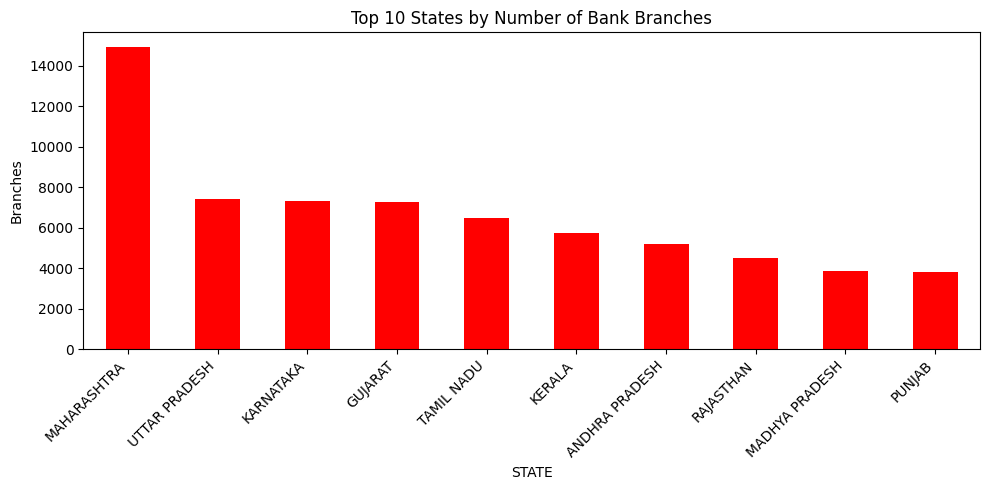

In [57]:
state_count.head(10).plot(kind = 'bar', figsize = (10, 5), color = 'r')
plt.title("Top 10 States by Number of Bank Branches")
plt.ylabel("Branches")
plt.xticks(rotation=45, ha="right") # rotation 45 angle and ha means horizontal alignment
plt.tight_layout()  # All elements(titles, labels, ticks, etc.) ko properly adjust
plt.show()

#### 2. Which banks have the most branches?

In [50]:
bank_counts = df['BANK'].value_counts()
print(bank_counts.head(20))

BANK
State Bank of India                10249
Bank of Baroda                      9026
HDFC Bank                           7968
Bank of India                       6693
Canara Bank                         5391
Central Bank of India               4498
UCO Bank                            2925
Indian Overseas Bank                2662
Axis Bank                           2646
Bank of Maharashtra                 1922
Kotak Mahindra Bank                 1828
Yes Bank                            1674
ICICI Bank                          1627
IDBI                                1623
Gujarat State Co-operative Bank     1462
Punjab National Bank                1413
Indusind Bank                       1410
Bandhan Bank                        1196
South Indian Bank                    914
Union Bank of India                  871
Name: count, dtype: int64


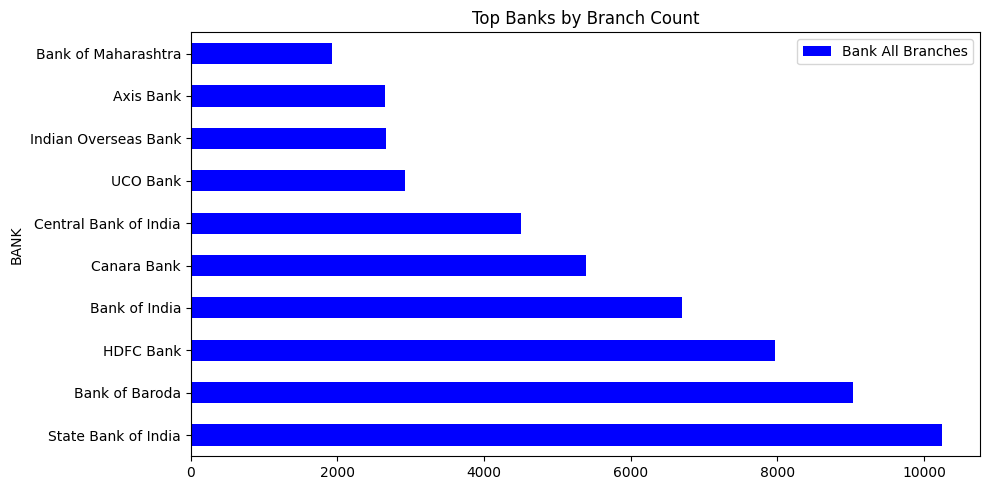

In [86]:
bank_counts.head(10).plot(kind = 'barh',figsize = (10, 5), color = 'b', label = 'Bank All Branches')
plt.legend()
plt.title("Top Banks by Branch Count")
plt.tight_layout()
plt.show()

#### 3. Which districts have the highest banking coverage?

In [97]:
dist = df['DISTRICT'].value_counts()
print(dist.head(10))

DISTRICT
PUNE               1815
DELHI              1302
BANGALORE URBAN    1243
GREATER BOMBAY     1169
CHENNAI            1158
THANE              1047
KOLKATA             962
HYDERABAD           907
MUMBAI              866
SURAT               750
Name: count, dtype: int64


* ('line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin')

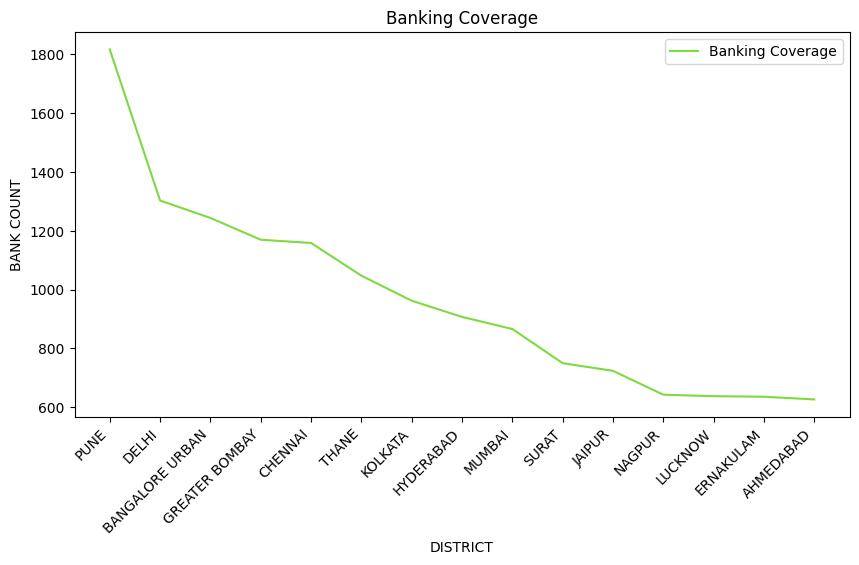

In [107]:
plt.figure(figsize=(10, 5))
plt.plot(dist.head(15), color='#7eda41', label='Banking Coverage')
plt.xlabel('DISTRICT')
plt.ylabel('BANK COUNT')
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.title("Banking Coverage")
plt.show()

#### 4.How many branches support

* NEFT
* RTGS
* IMPS
* UPI

In [111]:
digital = {
    'NEFT' : df['NEFT'].sum(),
    'RTGS' : df['RTGS'].sum(),
    'IMPS' : df['IMPS'].sum(),
    'UPI' : df['UPI'].sum()
}

In [112]:
digital

{'NEFT': np.int64(88947),
 'RTGS': np.int64(89209),
 'IMPS': np.int64(89208),
 'UPI': np.int64(83719)}

In [120]:
services = list(digital.keys())
values = list(digital.values())

print(services, values, sep='\n')

['NEFT', 'RTGS', 'IMPS', 'UPI']
[np.int64(88947), np.int64(89209), np.int64(89208), np.int64(83719)]


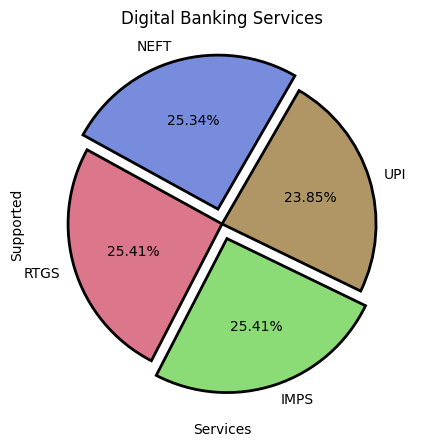

In [147]:
plt.figure(figsize=(10,5))
plt.pie(values, 
        labels = services, 
       colors = ['#778CDC','#DC778B','#8BDC77', '#B19665'],
        autopct='%1.2f%%', 
       wedgeprops = {'edgecolor' : 'black', 'linewidth' : 2},
       startangle = 60,
        explode=[0.1, 0, 0.1, 0])

plt.title('Digital Banking Services')
plt.xlabel('Services')
plt.ylabel('Supported')
plt.show()

* simple pie chart in Python    

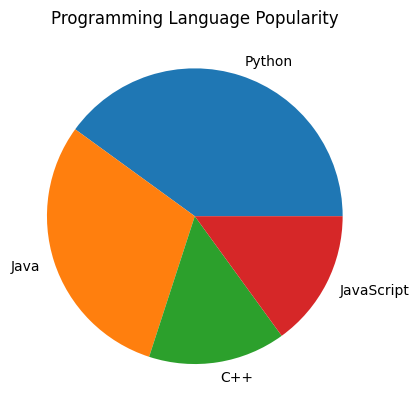

In [145]:

labels = ['Python', 'Java', 'C++', 'JavaScript']
sizes = [40, 30, 15, 15]

plt.pie(sizes, labels=labels)

plt.title("Programming Language Popularity")
plt.show()

#### 5. Which states have the highest UPI-enabled branches?

In [150]:
upi_state = df[df['UPI'] == True].groupby('STATE').size()

top_10 = upi_state.sort_values(ascending=False).head(10)

top_10

STATE
MAHARASHTRA       12975
UTTAR PRADESH      7370
GUJARAT            6924
KARNATAKA          6616
TAMIL NADU         6481
ANDHRA PRADESH     5152
KERALA             4763
RAJASTHAN          4453
MADHYA PRADESH     3832
PUNJAB             3800
dtype: int64

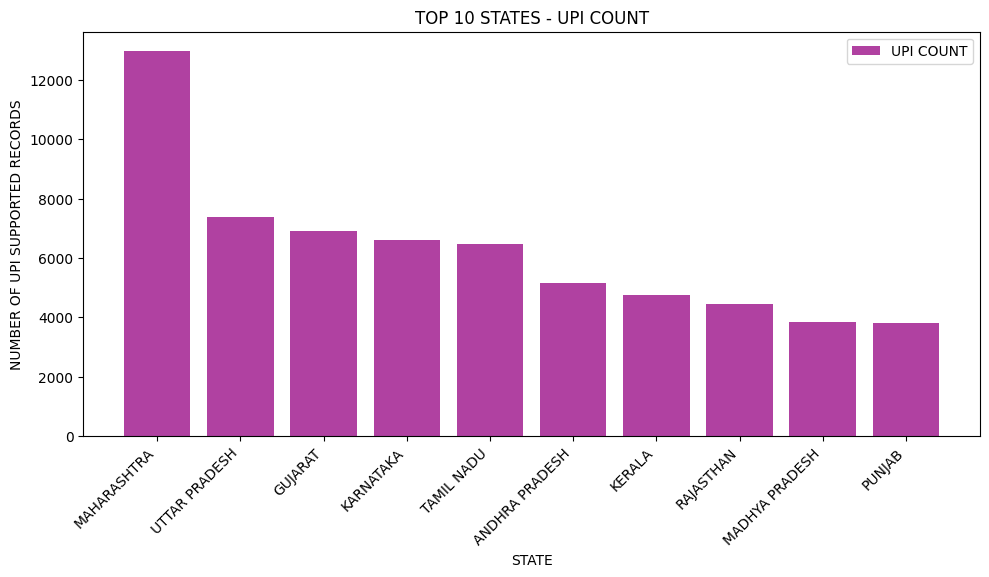

In [169]:
plt.figure(figsize=(10, 5))
plt.bar(top_10.index, top_10.values, color='#B041A1', label = 'UPI COUNT')
plt.legend()
plt.title('TOP 10 STATES - UPI COUNT')
plt.xlabel('STATE')
plt.ylabel('NUMBER OF UPI SUPPORTED RECORDS')
plt.tight_layout()
plt.xticks(rotation=45, ha='right') 
plt.show()

#### 6. Missing Contact Numbers

In [170]:
missing = df["CONTACT"].isna().sum()

print("Missing Contacts:", missing)

Missing Contacts: 0


#### 7. Branch Distribution by Bank and State

In [184]:
pivot = pd.pivot_table(
    df,
    index="BANK",
    columns="STATE",
    aggfunc="size",
    fill_value=0
)

print(pivot.head(1))

STATE                                               ANDAMAN AND NICOBAR ISLANDS  \
BANK                                                                              
510 Army Base W/s Credit Co-operative Primary Bank                            0   

STATE                                               ANDHRA PRADESH  \
BANK                                                                 
510 Army Base W/s Credit Co-operative Primary Bank               0   

STATE                                               ARUNACHAL PRADESH  ASSAM  \
BANK                                                                           
510 Army Base W/s Credit Co-operative Primary Bank                  0      0   

STATE                                               BIHAR  CHANDIGARH  \
BANK                                                                    
510 Army Base W/s Credit Co-operative Primary Bank      0           0   

STATE                                               CHHATTISGARH  \
BANK      

* Simple example to the `pivot_table()`

In [176]:
data = {
    'Region': ['East', 'West', 'East', 'West', 'East', 'West', 'East', 'West'],
    'Product': ['TV', 'TV', 'Laptop', 'Laptop', 'TV', 'TV', 'Laptop', 'Laptop'],
    'Sales': [1200, 1500, 800, 900, 1100, 1600, 850, 950],
    'Units': [4, 5, 2, 3, 4, 6, 2, 3]
}

df_x = pd.DataFrame(data)
pd.pivot_table(df_x, values='Sales',       # jis column ka mean chahiye
                       index='Region',       # rows
                       columns='Product',    # columns
                       aggfunc='mean', 
                       fill_value=0)

Product,Laptop,TV
Region,,
East,825.0,1150.0
West,925.0,1550.0


#### 8. Top Cities with Most Branches

Text(74.59722222222221, 0.5, 'NUMBER OF BANK BRANCHES')

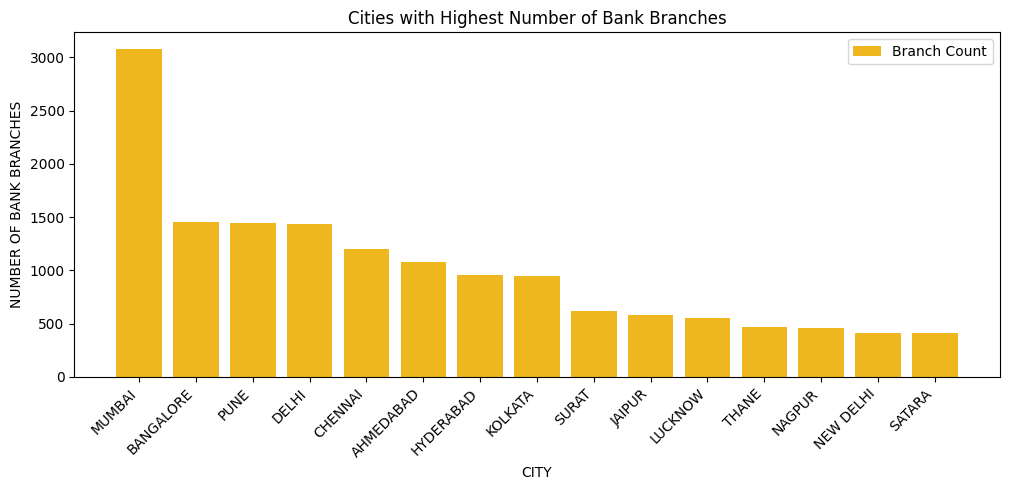

In [190]:
city = df["CITY"].value_counts()
top_15 = city.head(15)

plt.figure(figsize=(10, 5))

plt.bar(top_15.index, top_15.values, 
        color='#EEB71F', 
        label='Branch Count')

plt.legend()
plt.xticks(rotation=45, ha='right')
plt.title('Cities with Highest Number of Bank Branches')
plt.xlabel('CITY')
plt.tight_layout()
plt.ylabel('NUMBER OF BANK BRANCHES')

#### 9. Find Banks Present in Every State

In [191]:
bank_states = df.groupby("BANK")["STATE"].nunique()

total_states = df["STATE"].nunique()

national_banks = bank_states[bank_states == total_states]

print(national_banks)

BANK
HDFC Bank    35
UCO Bank     35
Name: STATE, dtype: int64


#### 10. IFSC Code Validation

In [192]:
invalid = df[~df["IFSC"].str.match(r'^[A-Z]{4}0[A-Z0-9]{6}$')]

print(invalid)

Empty DataFrame
Columns: [BANK, IFSC, BRANCH, CENTRE, DISTRICT, STATE, ADDRESS, CONTACT, IMPS, RTGS, CITY, ISO3166, NEFT, MICR, UPI]
Index: []


#### 11. Duplicate IFSC Detection

In [193]:
duplicates = df[df.duplicated("IFSC")]

print(duplicates)

Empty DataFrame
Columns: [BANK, IFSC, BRANCH, CENTRE, DISTRICT, STATE, ADDRESS, CONTACT, IMPS, RTGS, CITY, ISO3166, NEFT, MICR, UPI]
Index: []


#### 12. State-wise Digital Banking Percentage

In [194]:
state_digital = df.groupby("STATE")[["NEFT","RTGS","IMPS","UPI"]].mean()*100

print(state_digital.round(2))

                                            NEFT   RTGS    IMPS     UPI
STATE                                                                  
ANDAMAN AND NICOBAR ISLANDS               100.00  100.0  100.00  100.00
ANDHRA PRADESH                             99.86  100.0  100.00   99.48
ARUNACHAL PRADESH                          98.08  100.0  100.00  100.00
ASSAM                                      99.78  100.0  100.00  100.00
BIHAR                                      99.62  100.0  100.00  100.00
CHANDIGARH                                 99.73  100.0  100.00  100.00
CHHATTISGARH                               99.76  100.0  100.00   60.50
DADRA AND NAGAR HAVELI AND DAMAN AND DIU  100.00  100.0  100.00   97.33
DELHI                                      99.90  100.0  100.00   96.61
GOA                                        99.81  100.0  100.00   99.05
GUJARAT                                    99.67  100.0  100.00   95.50
HARYANA                                    99.42  100.0  100.00 

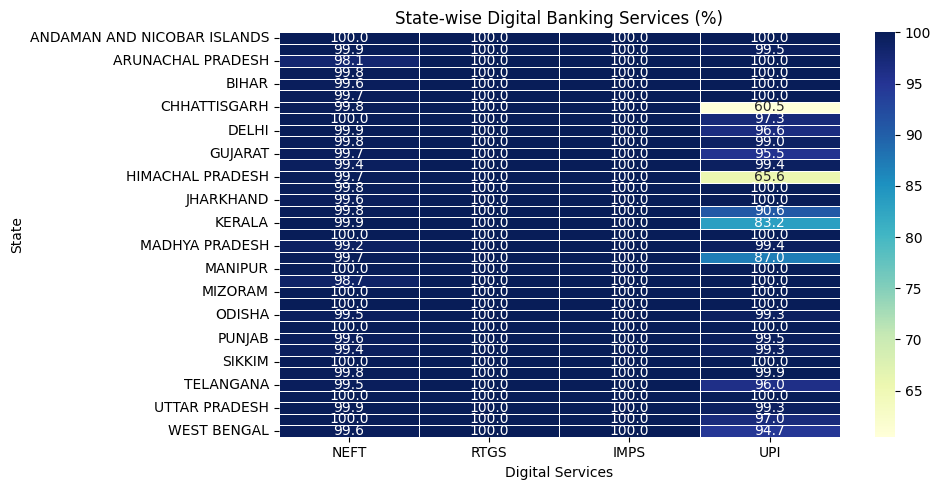

In [197]:
state_digital = state_digital.round(2)

plt.figure(figsize=(10,5))

sns.heatmap(state_digital, 
            annot=True,           # percentage values show karega
            fmt=".1f", 
            cmap="YlGnBu",        # color theme
            linewidths=0.5)

plt.title("State-wise Digital Banking Services (%)")
plt.xlabel("Digital Services")
plt.ylabel("State")

plt.tight_layout()
plt.show()

#### 13. Branches Without MICR Codes

In [198]:
no_micr = df[df["MICR"].isna()]

print(no_micr.head())

Empty DataFrame
Columns: [BANK, IFSC, BRANCH, CENTRE, DISTRICT, STATE, ADDRESS, CONTACT, IMPS, RTGS, CITY, ISO3166, NEFT, MICR, UPI]
Index: []


#### 14. Average Number of Branches per Bank

In [200]:
avg = df.groupby("BANK").size().mean().round(2)

print("Average branches per bank:", avg)

Average branches per bank: 95.82
